In [35]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

,Discharge1974-2002,Discharge2008-2023
Date,,
1983,353.044,NaN
1993,336.292,NaN
1994,332.691,NaN
1996,340.067,NaN
2015,NaN,337.660
2019,NaN,301.376
2021,NaN,342.440


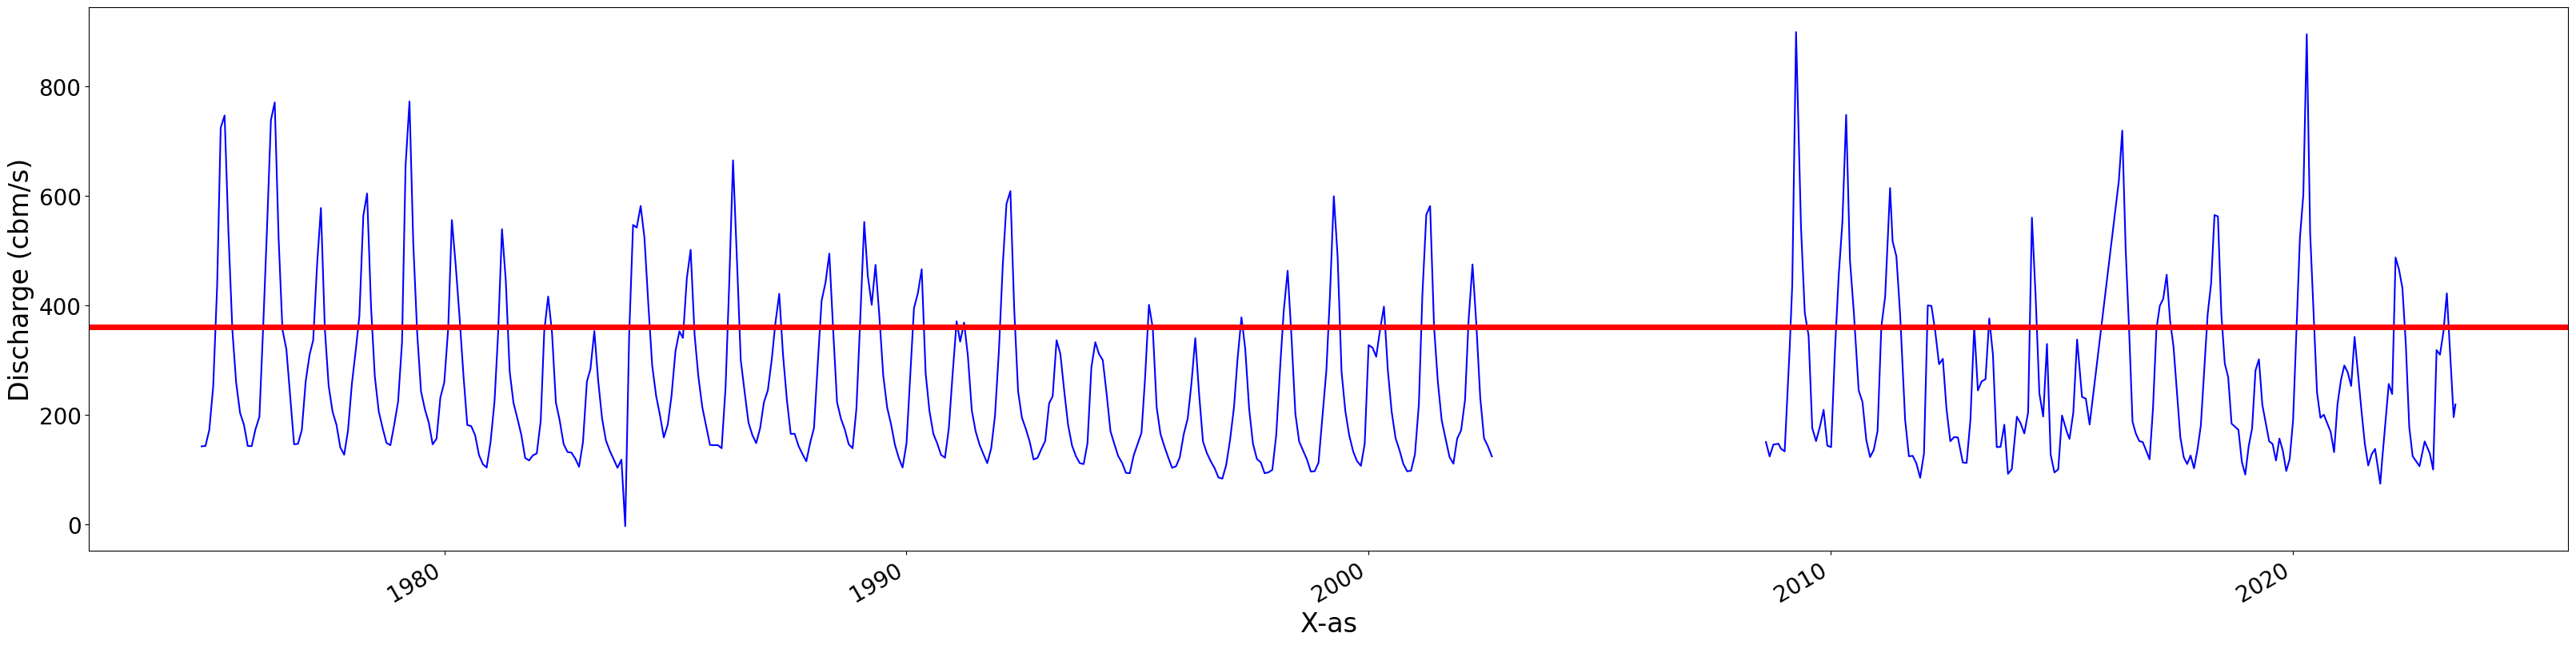

In [202]:
data1 = pd.read_csv("../BEP/data/Discharge data Mohembo 1974-2002.txt", index_col=0, sep="\t", parse_dates=True, 
                    date_format="%Y-%m", comment='#', header=None, names=["Date", "Discharge1974-2002"])
data2 = pd.read_csv("../BEP/data/Discharge data Mohembo 2008-2023.txt", sep=",", comment='#', 
                    header=None, names=["YYYY", "MM", "DD", "Discharge2008-2023", "Error"])
data2["Date"] = pd.to_datetime(dict(year=data2.iloc[:,0], month=data2.iloc[:,1], day=data2.iloc[:,2]))
data2 = data2.drop(columns=["YYYY", "MM", "DD", "Error"])
data2 = data2.set_index("Date")
combined = pd.concat([data1, data2])

fig, ax = plt.subplots(figsize=(40, 10))
combined.plot(ax=ax, color='blue', legend=False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("X-as", fontsize=24)
ax.set_ylabel("Discharge (cbm/s)", fontsize=24)
plt.axhline(y=360, color='red', linewidth=5);

yearly_max = combined.groupby(combined.index.year).max()
filtered_years1 = yearly_max[(yearly_max["Discharge1974-2002"] > 180) & (yearly_max["Discharge1974-2002"] < 360)]
filtered_years2 = yearly_max[(yearly_max["Discharge2008-2023"] > 160) & (yearly_max["Discharge2008-2023"] < 360)]
filtered_years = pd.concat([filtered_years1, filtered_years2])
filtered_years